# 🔧 Day 25: GPU FinOps & Cost Optimization - Hands-on Lab

This notebook connects to a local Docker Compose cluster (via ngrok/cloudflared tunnel) to demonstrate:
1. **GPU Cluster Monitoring** - Real-time GPU metrics
2. **Cost Tracking (OpenCost-like)** - Per-node cost allocation & waste analysis
3. **Spot Instance Management** - Bidding, preemption, savings
4. **Autoscaling (KEDA-like)** - Policy-based GPU scaling
5. **Budget Management & Forecasting** - Alerts, burn rate

## Prerequisites
- Docker Compose running locally with the GPU FinOps Lab services
- Tunnel exposed via ngrok or cloudflared (free tier)

In [5]:
# Cell 1: Setup
!pip install -q requests pandas matplotlib plotly

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from IPython.display import display, HTML, clear_output

In [6]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Bùi Quang Vinh"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600007"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [7]:
# Cell 2: Configure Gateway URL
# Replace with your ngrok/cloudflared URL after running the tunnel
GATEWAY_URL = "https://connected-healthcare-strengthen-accessed.trycloudflare.com"  # <-- CHANGE THIS

# Test connection
try:
    r = requests.get(f"{GATEWAY_URL}/", timeout=10)
    print("✅ Connected to GPU FinOps Lab Gateway")
    print(json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Make sure Docker Compose is running and tunnel is active")

✅ Connected to GPU FinOps Lab Gateway
{
  "service": "GPU FinOps Lab Gateway",
  "endpoints": {
    "cluster": "/cluster/*",
    "billing": "/billing/*",
    "spot": "/spot/*",
    "autoscaler": "/autoscaler/*",
    "cost": "/cost/*"
  }
}


---
## Part 1: GPU Cluster Monitoring
Observe the mock GPU cluster state — nodes, utilization, memory, power draw.

In [8]:
# Cell 3: View Cluster Nodes
if "display_student_header" in globals():
    display_student_header()

nodes = requests.get(f"{GATEWAY_URL}/cluster/nodes").json()

print(f"📊 Cluster has {len(nodes)} nodes")
print("=" * 60)

for node_id, gpus in nodes.items():
    print(f"\n🖥️  {node_id}:")
    for gpu in gpus:
        status_icon = "🟢" if gpu['status'] == 'idle' else "🔴"
        print(f"   GPU {gpu['gpu_id']} [{gpu['gpu_type']}] {status_icon} "
              f"Util: {gpu['utilization']:.1f}% | "
              f"Mem: {gpu['memory_used_gb']:.1f}/{gpu['memory_total_gb']}GB | "
              f"Power: {gpu['power_draw_watts']:.0f}W | "
              f"Temp: {gpu['temperature_c']:.0f}°C")

📊 Cluster has 7 nodes

🖥️  node-00:
   GPU 0 [T4] 🔴 Util: 64.5% | Mem: 12.2/16.0GB | Power: 49W | Temp: 81°C
   GPU 1 [T4] 🔴 Util: 70.3% | Mem: 11.7/16.0GB | Power: 60W | Temp: 61°C

🖥️  node-01:
   GPU 0 [A100] 🔴 Util: 71.5% | Mem: 62.7/80.0GB | Power: 278W | Temp: 71°C
   GPU 1 [A100] 🔴 Util: 86.4% | Mem: 44.3/80.0GB | Power: 240W | Temp: 73°C

🖥️  node-02:
   GPU 0 [V100] 🔴 Util: 60.2% | Mem: 22.7/32.0GB | Power: 230W | Temp: 67°C
   GPU 1 [V100] 🟢 Util: 6.5% | Mem: 1.0/32.0GB | Power: 25W | Temp: 34°C

🖥️  node-03:
   GPU 0 [T4] 🔴 Util: 89.0% | Mem: 13.5/16.0GB | Power: 61W | Temp: 56°C
   GPU 1 [T4] 🔴 Util: 92.2% | Mem: 10.1/16.0GB | Power: 55W | Temp: 64°C

🖥️  node-04:
   GPU 0 [T4] 🔴 Util: 73.0% | Mem: 10.1/16.0GB | Power: 46W | Temp: 75°C
   GPU 1 [T4] 🔴 Util: 63.1% | Mem: 12.8/16.0GB | Power: 58W | Temp: 81°C

🖥️  node-05:
   GPU 0 [T4] 🔴 Util: 79.1% | Mem: 9.9/16.0GB | Power: 53W | Temp: 81°C
   GPU 1 [T4] 🔴 Util: 64.9% | Mem: 12.9/16.0GB | Power: 66W | Temp: 72°C

🖥️  node-

In [9]:
# Cell 4: Cluster Metrics Summary
if "display_student_header" in globals():
    display_student_header()

metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()

print("📈 Cluster Metrics")
print("=" * 40)
print(f"Total GPUs:          {metrics['total_gpus']}")
print(f"Busy GPUs:           {metrics['busy_gpus']}")
print(f"Idle GPUs:           {metrics['idle_gpus']}")
print(f"Avg Utilization:     {metrics['avg_utilization']:.1f}%")
print(f"Memory Used:         {metrics['total_memory_used_gb']:.1f} GB")
print(f"Memory Capacity:     {metrics['total_memory_capacity_gb']:.1f} GB")
print(f"Total Power Draw:    {metrics['total_power_draw_watts']:.0f} W")
print(f"Node Count:          {metrics['node_count']}")

📈 Cluster Metrics
Total GPUs:          14
Busy GPUs:           11
Idle GPUs:           3
Avg Utilization:     58.6%
Memory Used:         224.9 GB
Memory Capacity:     384.0 GB
Total Power Draw:    1261 W
Node Count:          7


---
## Part 2: Workload Submission & Cost Tracking
Submit GPU workloads and track their costs in real-time.

In [10]:
# Cell 5: Submit multiple workloads
if "display_student_header" in globals():
    display_student_header()

workloads = [
    {"workload_id": "train-resnet-001", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 300},
    {"workload_id": "train-bert-002", "gpu_type_preferred": "A100", "gpu_count": 1, "duration_seconds": 600},
    {"workload_id": "inference-api-003", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 120},
    {"workload_id": "train-llm-004", "gpu_type_preferred": "A100", "gpu_count": 2, "duration_seconds": 900},
]

print("🚀 Submitting workloads...")
for wl in workloads:
    r = requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json=wl)
    result = r.json()
    print(f"   {wl['workload_id']}: {result['status']} → {result.get('assigned', 'queued')}")

# Check cluster state after submission
print("\n📊 Updated metrics:")
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   Busy GPUs: {metrics['busy_gpus']}/{metrics['total_gpus']} | Utilization: {metrics['avg_utilization']:.1f}%")

🚀 Submitting workloads...
   train-resnet-001: running → [{'node_id': 'node-06', 'gpu_id': 0}]
   train-bert-002: running → [{'node_id': 'node-02', 'gpu_id': 1}]
   inference-api-003: running → [{'node_id': 'node-06', 'gpu_id': 1}]
   train-llm-004: queued → queued

📊 Updated metrics:
   Busy GPUs: 14/14 | Utilization: 76.3%


In [11]:
# Cell 6: Record billing for workloads
if "display_student_header" in globals():
    display_student_header()

billing_events = [
    {"workload_id": "train-resnet-001", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 300, "is_spot": False},
    {"workload_id": "train-bert-002", "gpu_type": "A100", "gpu_count": 1, "duration_seconds": 600, "is_spot": False},
    {"workload_id": "inference-api-003", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 120, "is_spot": True},
    {"workload_id": "train-llm-004", "gpu_type": "A100", "gpu_count": 2, "duration_seconds": 900, "is_spot": True},
]

print("💰 Recording billing events...")
for event in billing_events:
    r = requests.post(f"{GATEWAY_URL}/billing/record", json=event)
    result = r.json()
    spot_label = "[SPOT]" if event['is_spot'] else "[ON-DEMAND]"
    print(f"   {event['workload_id']} {spot_label}: ${result['total_cost_usd']:.4f} "
          f"(saved ${result['savings_usd']:.4f})")

# Get billing summary
print("\n📋 Billing Summary:")
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total Cost:     ${summary['total_cost_usd']:.4f}")
print(f"   Total Savings:  ${summary['total_savings_usd']:.4f}")
print(f"   Budget Used:    {summary['budget_utilization_pct']:.1f}%")
print(f"   Alert Status:   {summary['alert']}")

💰 Recording billing events...
   train-resnet-001 [ON-DEMAND]: $0.0292 (saved $0.0000)
   train-bert-002 [ON-DEMAND]: $0.6117 (saved $0.0000)
   inference-api-003 [SPOT]: $0.0035 (saved $0.0082)
   train-llm-004 [SPOT]: $0.5505 (saved $1.2845)

📋 Billing Summary:
   Total Cost:     $3.9229
   Total Savings:  $4.1229
   Budget Used:    3.9%
   Alert Status:   OK


---
## Part 3: Spot Instance Management
Demonstrate spot bidding, preemption handling, and cost savings.

In [12]:
# Cell 7: Check spot pricing
if "display_student_header" in globals():
    display_student_header()

spot_pricing = requests.get(f"{GATEWAY_URL}/spot/pricing").json()

print("💹 Current Spot Pricing")
print("=" * 60)
print(f"{'GPU Type':<10} {'On-Demand':<12} {'Spot Price':<12} {'Discount':<10} {'Availability'}")
print("-" * 60)
for gpu, info in spot_pricing.items():
    print(f"{gpu:<10} ${info['on_demand_price']:<10.2f} ${info['current_spot_price']:<10.4f} "
          f"{info['discount_pct']:<8.1f}% {info['availability']}")

💹 Current Spot Pricing
GPU Type   On-Demand    Spot Price   Discount   Availability
------------------------------------------------------------
T4         $0.35       $0.2450     30.0    % low
A100       $3.67       $2.3385     36.3    % low
V100       $2.48       $1.7510     29.4    % low
P100       $1.46       $1.0347     29.1    % low
L4         $0.81       $0.6457     20.3    % low


In [13]:
# Cell 8: Request spot instances
if "display_student_header" in globals():
    display_student_header()

spot_requests = [
    {"instance_id": "spot-t4-001", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": "batch-job-1"},
    {"instance_id": "spot-t4-002", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.12, "workload_id": "batch-job-2"},
    {"instance_id": "spot-a100-001", "gpu_type": "A100", "gpu_count": 1, "max_price_per_hour": 1.50, "workload_id": "training-3"},
]

print("🎯 Requesting Spot Instances...")
for req in spot_requests:
    r = requests.post(f"{GATEWAY_URL}/spot/request", json=req)
    result = r.json()
    status_icon = "✅" if result['status'] == 'granted' else "❌"
    print(f"   {status_icon} {req['instance_id']} ({req['gpu_type']}): {result['status']}")
    if result['status'] == 'rejected':
        print(f"      Reason: {result.get('reason', 'N/A')}")

🎯 Requesting Spot Instances...
   ✅ spot-t4-001 (T4): granted
   ✅ spot-t4-002 (T4): granted
   ✅ spot-a100-001 (A100): granted


In [14]:
# Cell 9: Simulate spot preemption
if "display_student_header" in globals():
    display_student_header()

print("⚡ Simulating spot preemption event...")
preemption = requests.post(f"{GATEWAY_URL}/spot/simulate-preemption").json()

print(f"\n   Preempted instances: {preemption['preempted_count']}")
print(f"   Still active: {preemption['total_active']}")

if preemption['preempted_instances']:
    print("\n   ⚠️  Preempted:")
    for p in preemption['preempted_instances']:
        print(f"      - {p['instance_id']} (ran for {p['runtime_seconds']:.0f}s, "
              f"{p['notice_seconds']}s warning)")

# Savings report
print("\n💰 Spot Savings Report:")
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot cost:        ${savings['total_spot_cost']:.4f}")
print(f"   On-demand equiv:  ${savings['on_demand_equivalent']:.4f}")
print(f"   Total saved:      ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

⚡ Simulating spot preemption event...

   Preempted instances: 0
   Still active: 6

💰 Spot Savings Report:
   Spot cost:        $0.2328
   On-demand equiv:  $0.7761
   Total saved:      $0.5432 (70.0%)


---
## Part 4: Autoscaling (KEDA-like)
Configure and trigger GPU autoscaling based on utilization thresholds.

In [15]:
# Cell 10: View and update autoscaling policy
if "display_student_header" in globals():
    display_student_header()

policy = requests.get(f"{GATEWAY_URL}/autoscaler/policy").json()
print("📜 Current Autoscaling Policy:")
for k, v in policy.items():
    print(f"   {k}: {v}")

# Update policy - more aggressive scaling
new_policy = {
    "scale_up_threshold": 70,
    "scale_down_threshold": 25,
    "cooldown_seconds": 30,
    "max_nodes": 10,
    "min_nodes": 2,
    "preferred_gpu_type": "T4",
    "cost_aware": True
}

print("\n🔄 Updating policy...")
updated = requests.post(f"{GATEWAY_URL}/autoscaler/policy", json=new_policy).json()
print("   ✅ Policy updated")

📜 Current Autoscaling Policy:
   scale_up_threshold: 70.0
   scale_down_threshold: 25.0
   cooldown_seconds: 30
   max_nodes: 10
   min_nodes: 2
   preferred_gpu_type: T4
   cost_aware: True

🔄 Updating policy...
   ✅ Policy updated


In [16]:
# Cell 11: Trigger autoscaler evaluation
if "display_student_header" in globals():
    display_student_header()

print("🔄 Evaluating autoscaling decision...")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()

action_icons = {"scale_up": "⬆️", "scale_down": "⬇️", "no_action": "➡️"}
print(f"\n   {action_icons.get(decision['action'], '❓')} Action: {decision['action'].upper()}")
print(f"   Reason: {decision['reason']}")
print(f"   Current utilization: {decision['current_utilization']:.1f}%")
print(f"   Nodes: {decision['node_count']} → {decision['target_node_count']}")

# Run multiple evaluations to show scaling behavior
print("\n📊 Running 5 evaluation cycles...")
for i in range(5):
    time.sleep(2)
    d = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
    print(f"   Cycle {i+1}: {d['action']:<12} | Util: {d['current_utilization']:.1f}% | Nodes: {d['node_count']}→{d['target_node_count']}")

🔄 Evaluating autoscaling decision...

   ⬆️ Action: SCALE_UP
   Reason: Utilization 76.3% > threshold 70.0%
   Current utilization: 76.3%
   Nodes: 7 → 8

📊 Running 5 evaluation cycles...
   Cycle 1: no_action    | Util: 66.8% | Nodes: 8→8
   Cycle 2: no_action    | Util: 66.8% | Nodes: 8→8
   Cycle 3: no_action    | Util: 66.8% | Nodes: 8→8
   Cycle 4: no_action    | Util: 66.8% | Nodes: 8→8
   Cycle 5: no_action    | Util: 66.8% | Nodes: 8→8


---
## Part 5: Cost Analysis & Optimization (OpenCost-like)
Analyze cost allocation, identify waste, and get recommendations.

In [17]:
# Cell 12: Take cost snapshots
if "display_student_header" in globals():
    display_student_header()

print("📸 Taking cost snapshots...")
snapshots = []
for i in range(5):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    snapshots.append(snap)
    print(f"   Snapshot {i+1}: Total=${snap['total_cost_usd']:.6f} | "
          f"Idle=${snap['total_idle_cost_usd']:.6f} | "
          f"Waste={snap['waste_pct']:.1f}%")
    time.sleep(1)

📸 Taking cost snapshots...
   Snapshot 1: Total=$0.045833 | Idle=$0.001944 | Waste=4.2%
   Snapshot 2: Total=$0.045833 | Idle=$0.001944 | Waste=4.2%
   Snapshot 3: Total=$0.045833 | Idle=$0.001944 | Waste=4.2%
   Snapshot 4: Total=$0.045833 | Idle=$0.001944 | Waste=4.2%
   Snapshot 5: Total=$0.045833 | Idle=$0.001944 | Waste=4.2%


In [18]:
# Cell 13: Waste Report
if "display_student_header" in globals():
    display_student_header()

waste = requests.get(f"{GATEWAY_URL}/cost/waste-report").json()

print("🗑️  WASTE ANALYSIS REPORT")
print("=" * 50)
print(f"   Average Waste:          {waste.get('avg_waste_pct', 0):.1f}%")
print(f"   Total Idle Cost:        ${waste.get('total_idle_cost_usd', 0):.6f}")
print(f"   Total Cost:             ${waste.get('total_cost_usd', 0):.6f}")
print(f"   Potential Monthly Save:  ${waste.get('potential_monthly_savings', 0):.2f}")
print(f"   Severity:               {waste.get('severity', 'N/A')}")

🗑️  WASTE ANALYSIS REPORT
   Average Waste:          6.0%
   Total Idle Cost:        $0.026329
   Total Cost:             $0.442775
   Potential Monthly Save:  $682.45
   Severity:               LOW


In [19]:
# Cell 14: Get Optimization Recommendations
if "display_student_header" in globals():
    display_student_header()

recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()

print("💡 COST OPTIMIZATION RECOMMENDATIONS")
print("=" * 60)
for i, rec in enumerate(recs, 1):
    priority_icons = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
    icon = priority_icons.get(rec['priority'], '⚪')
    print(f"\n{i}. {icon} [{rec['priority']}] {rec['type']}")
    print(f"   {rec['description']}")
    print(f"   Estimated savings: {rec['estimated_savings_pct']:.1f}%")

💡 COST OPTIMIZATION RECOMMENDATIONS

1. 🟡 [MEDIUM] USE_SPOT
   Switch fault-tolerant workloads to spot instances for 60-70% savings.
   Estimated savings: 65.0%

2. 🟢 [LOW] SCHEDULING
   Schedule non-urgent training jobs during off-peak hours for lower spot prices.
   Estimated savings: 20.0%


In [20]:
# Cell 15: Full Dashboard View
if "display_student_header" in globals():
    display_student_header()

dashboard = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()

print("📊 GPU FinOps DASHBOARD")
print("=" * 60)

cm = dashboard.get('cluster_metrics', {})
print(f"\n🖥️  CLUSTER: {cm.get('total_gpus', 0)} GPUs across {cm.get('node_count', 0)} nodes")
print(f"   Utilization: {cm.get('avg_utilization', 0):.1f}% | Busy: {cm.get('busy_gpus', 0)} | Idle: {cm.get('idle_gpus', 0)}")

bs = dashboard.get('billing_summary', {})
print(f"\n💰 BILLING: ${bs.get('total_cost_usd', 0):.4f} / ${bs.get('budget_usd', 0):.2f} budget")
print(f"   Alert: {bs.get('alert', 'N/A')} | Savings: ${bs.get('total_savings_usd', 0):.4f}")

ss = dashboard.get('spot_savings', {})
print(f"\n🎯 SPOT: Saved ${ss.get('total_savings', 0):.4f} ({ss.get('savings_pct', 0):.1f}%)")

wa = dashboard.get('waste_analysis', {})
if wa:
    print(f"\n🗑️  WASTE: {wa.get('avg_waste_pct', 0):.1f}% | Severity: {wa.get('severity', 'N/A')}")

📊 GPU FinOps DASHBOARD

🖥️  CLUSTER: 16 GPUs across 8 nodes
   Utilization: 66.8% | Busy: 14 | Idle: 2

💰 BILLING: $3.9229 / $100.00 budget
   Alert: OK | Savings: $4.1229

🎯 SPOT: Saved $0.5667 (70.0%)

🗑️  WASTE: 6.0% | Severity: LOW


---
## Part 6: Visualization
Create charts for cost breakdown and utilization trends.

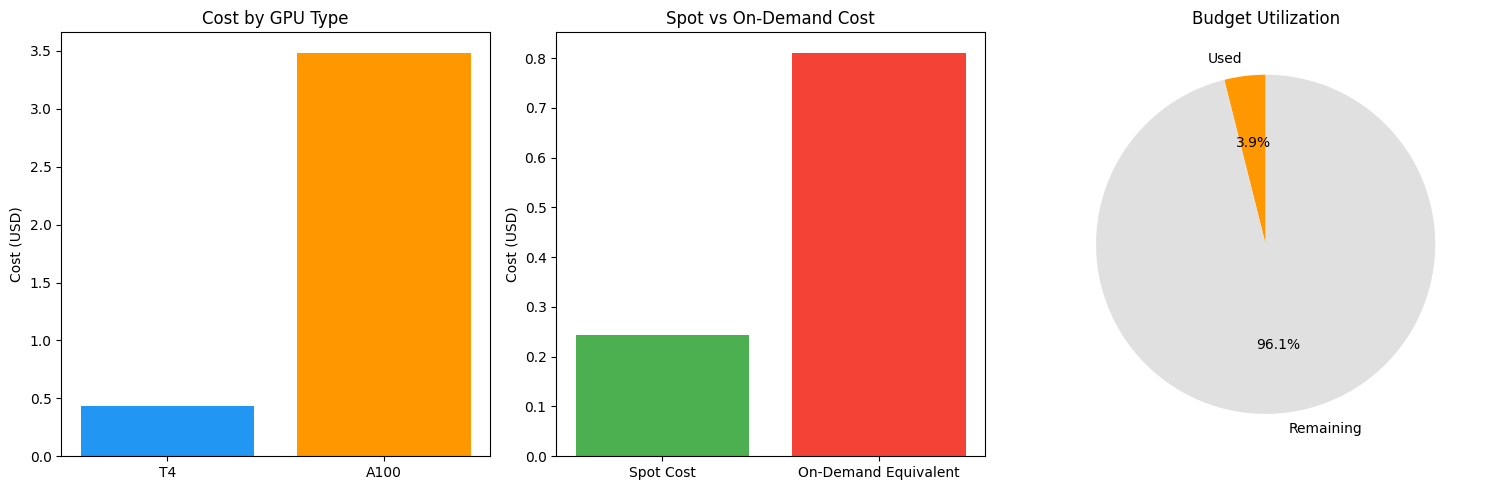

📊 Chart saved as finops_cost_breakdown.png


In [21]:
# Cell 16: Cost Breakdown Visualization
if "display_student_header" in globals():
    display_student_header()

summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Cost by GPU type
cost_by_type = summary.get('cost_by_gpu_type', {})
if cost_by_type:
    types = list(cost_by_type.keys())
    costs = [cost_by_type[t]['cost'] for t in types]
    axes[0].bar(types, costs, color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[0].set_title('Cost by GPU Type')
    axes[0].set_ylabel('Cost (USD)')

# Chart 2: Spot vs On-Demand
spot_data = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
labels = ['Spot Cost', 'On-Demand Equivalent']
values = [spot_data.get('total_spot_cost', 0), spot_data.get('on_demand_equivalent', 0)]
axes[1].bar(labels, values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Spot vs On-Demand Cost')
axes[1].set_ylabel('Cost (USD)')

# Chart 3: Budget utilization
budget_used = summary.get('budget_utilization_pct', 0)
axes[2].pie([budget_used, 100-budget_used], labels=['Used', 'Remaining'],
            colors=['#FF9800', '#E0E0E0'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Budget Utilization')

plt.tight_layout()
plt.savefig('finops_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as finops_cost_breakdown.png")

📈 Collecting time-series data (10 snapshots)...


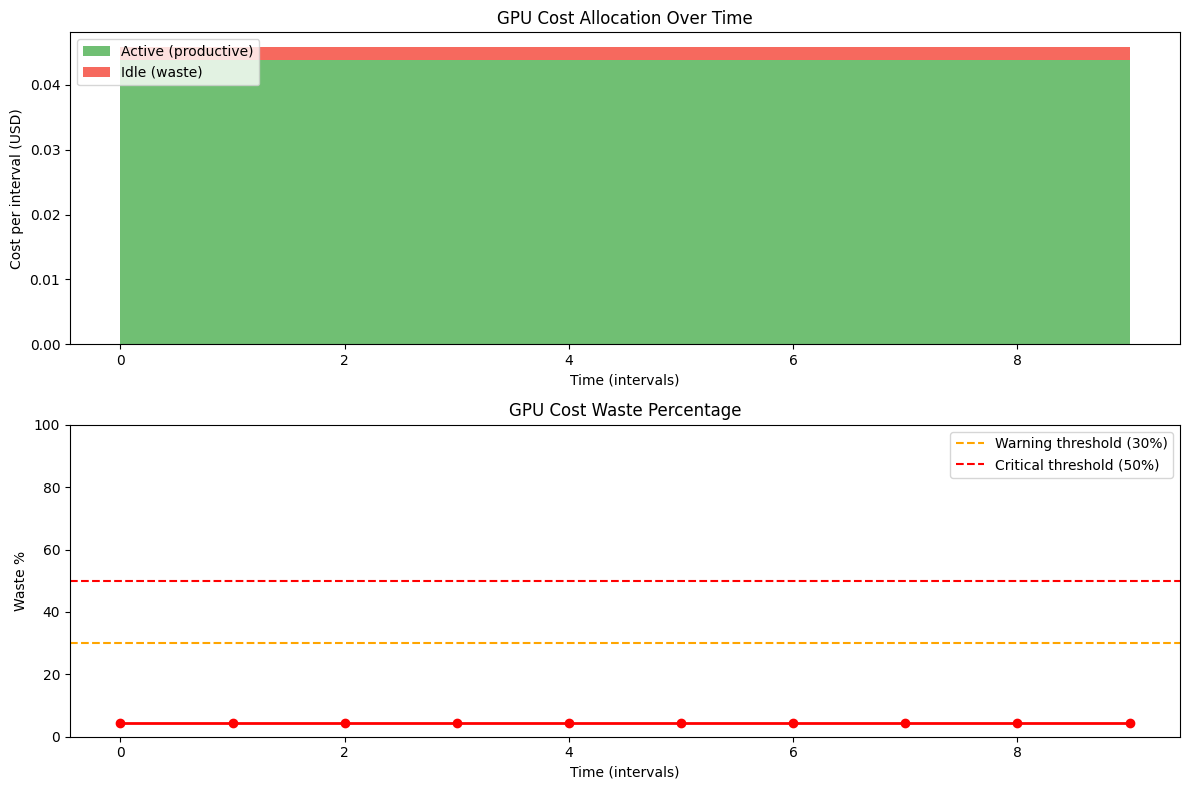

In [22]:
# Cell 17: Time-series cost tracking
if "display_student_header" in globals():
    display_student_header()

print("📈 Collecting time-series data (10 snapshots)...")
ts_data = []
for i in range(10):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    ts_data.append({
        'time': i,
        'total_cost': snap['total_cost_usd'],
        'idle_cost': snap['total_idle_cost_usd'],
        'active_cost': snap['total_active_cost_usd'],
        'waste_pct': snap['waste_pct'],
    })
    time.sleep(1)

df = pd.DataFrame(ts_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Cost over time
ax1.stackplot(df['time'], df['active_cost'], df['idle_cost'],
              labels=['Active (productive)', 'Idle (waste)'],
              colors=['#4CAF50', '#F44336'], alpha=0.8)
ax1.set_xlabel('Time (intervals)')
ax1.set_ylabel('Cost per interval (USD)')
ax1.set_title('GPU Cost Allocation Over Time')
ax1.legend(loc='upper left')

# Waste percentage
ax2.plot(df['time'], df['waste_pct'], 'r-o', linewidth=2)
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Time (intervals)')
ax2.set_ylabel('Waste %')
ax2.set_title('GPU Cost Waste Percentage')
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('finops_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7: Complete FinOps Workflow
Run a full cycle: submit workloads → monitor → detect waste → autoscale → optimize cost.

In [23]:
# Cell 18: Full FinOps Optimization Workflow
if "display_student_header" in globals():
    display_student_header()

print("🔄 FULL FINOPS OPTIMIZATION WORKFLOW")
print("=" * 60)

# Step 1: Check initial state
print("\n1️⃣  Initial cluster state:")
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   GPUs: {m['total_gpus']} | Util: {m['avg_utilization']:.1f}% | Idle: {m['idle_gpus']}")

# Step 2: Submit heavy workloads to increase utilization
print("\n2️⃣  Submitting heavy workloads...")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 600
    })
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   After load: Util: {m['avg_utilization']:.1f}% | Busy: {m['busy_gpus']}/{m['total_gpus']}")

# Step 3: Autoscaler evaluates
print("\n3️⃣  Autoscaler evaluation:")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
print(f"   Decision: {decision['action']} - {decision['reason']}")

# Step 4: Cost snapshot
print("\n4️⃣  Cost analysis:")
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"   Total cost/interval: ${snap['total_cost_usd']:.6f}")
print(f"   Waste: {snap['waste_pct']:.1f}%")

# Step 5: Get recommendations
print("\n5️⃣  Recommendations:")
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()
for rec in recs:
    print(f"   [{rec['priority']}] {rec['type']}: savings ~{rec['estimated_savings_pct']}%")

# Step 6: Apply optimization - use spot for some workloads
print("\n6️⃣  Applying optimization: Switch to spot instances...")
for i in range(3):
    requests.post(f"{GATEWAY_URL}/spot/request", json={
        "instance_id": f"opt-spot-{i}", "gpu_type": "T4",
        "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": f"heavy-{i:03d}"
    })

savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot savings: ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

# Step 7: Complete workloads and record billing
print("\n7️⃣  Final billing:")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/heavy-{i:03d}/complete")
    requests.post(f"{GATEWAY_URL}/billing/record", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type": "T4",
        "gpu_count": 1, "duration_seconds": 600, "is_spot": i < 3
    })

final = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total spend: ${final['total_cost_usd']:.4f}")
print(f"   Total saved: ${final['total_savings_usd']:.4f}")
print(f"   Budget: {final['budget_utilization_pct']:.1f}% used")
print(f"\n✅ Workflow complete!")

🔄 FULL FINOPS OPTIMIZATION WORKFLOW

1️⃣  Initial cluster state:
   GPUs: 16 | Util: 66.8% | Idle: 2

2️⃣  Submitting heavy workloads...
   After load: Util: 77.7% | Busy: 16/16

3️⃣  Autoscaler evaluation:
   Decision: scale_up - Utilization 77.7% > threshold 70.0%

4️⃣  Cost analysis:
   Total cost/interval: $0.047778
   Waste: 4.1%

5️⃣  Recommendations:
   [MEDIUM] USE_SPOT: savings ~65.0%
   [LOW] SCHEDULING: savings ~20.0%

6️⃣  Applying optimization: Switch to spot instances...
   Spot savings: $0.0424 (70.0%)

7️⃣  Final billing:
   Total spend: $4.0920
   Total saved: $4.2453
   Budget: 4.1% used

✅ Workflow complete!


---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** to measure time & cost savings
4. Reports all costs back to the FinOps gateway

In [24]:
# Cell 19: Install dependencies & detect real GPU
if "display_student_header" in globals():
    display_student_header()

!pip install -q torch torchvision pynvml

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import subprocess
import threading

try:
    from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex,
                        nvmlDeviceGetUtilizationRates, nvmlDeviceGetMemoryInfo,
                        nvmlDeviceGetPowerUsage, nvmlDeviceGetTemperature)
    PYNVML_AVAILABLE = True
except ImportError:
    PYNVML_AVAILABLE = False
    print("pynvml not available, will use torch.cuda fallback for monitoring")

# Detect GPU
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Enable GPU in Kaggle/Colab settings.")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

# Map real GPU to pricing
GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
detected_type = "T4"  # default
for gtype in GPU_PRICING:
    if gtype.lower() in gpu_name.lower():
        detected_type = gtype
        break

print(f"Real GPU Detected")
print(f"   Name:    {gpu_name}")
print(f"   Memory:  {gpu_mem:.1f} GB")
print(f"   Type:    {detected_type}")
print(f"   Pricing: ${GPU_PRICING[detected_type]:.2f}/hr (on-demand)")
print(f"   CUDA:    {torch.version.cuda}")
print(f"   pynvml:  {'available' if PYNVML_AVAILABLE else 'NOT available'}")

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Real GPU Detected
   Name:    Tesla T4
   Memory:  15.6 GB
   Type:    T4
   Pricing: $0.35/hr (on-demand)
   CUDA:    12.8
   pynvml:  available


In [25]:
# Cell 20: GPU Metrics Collection (works on Kaggle/Colab)
if "display_student_header" in globals():
    display_student_header()

# Strategy: pynvml first (reliable Python lib), torch.cuda fallback

def get_gpu_metrics():
    """Get GPU metrics inline. Called during training loop."""

    # Method 1: pynvml (most reliable on Kaggle - pure Python, no subprocess)
    if PYNVML_AVAILABLE:
        try:
            nvmlInit()
            handle = nvmlDeviceGetHandleByIndex(0)
            util = nvmlDeviceGetUtilizationRates(handle)
            mem_info = nvmlDeviceGetMemoryInfo(handle)
            try:
                power = nvmlDeviceGetPowerUsage(handle) / 1000.0  # mW -> W
            except Exception:
                power = 0.0
            try:
                temp = nvmlDeviceGetTemperature(handle, 0)  # NVML_TEMPERATURE_GPU = 0
            except Exception:
                temp = 0.0
            return {
                'timestamp': time.time(),
                'gpu_util_pct': float(util.gpu),
                'mem_util_pct': float(util.memory),
                'mem_used_mb': mem_info.used / 1e6,
                'mem_total_mb': mem_info.total / 1e6,
                'power_watts': float(power),
                'temp_c': float(temp),
            }
        except Exception as e:
            pass  # Fall through to torch.cuda

    # Method 2: torch.cuda (always works, limited metrics)
    mem_used = torch.cuda.memory_allocated() / 1e6
    mem_reserved = torch.cuda.memory_reserved() / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    util_approx = (mem_reserved / mem_total) * 100 if mem_total > 0 else 0
    return {
        'timestamp': time.time(),
        'gpu_util_pct': util_approx,
        'mem_util_pct': util_approx,
        'mem_used_mb': mem_used,
        'mem_total_mb': mem_total,
        'power_watts': 0.0,
        'temp_c': 0.0,
    }

# === DIAGNOSTIC TEST ===
print("=" * 50)
print("GPU METRICS DIAGNOSTIC")
print("=" * 50)

# Test pynvml
print(f"\n1. pynvml available: {PYNVML_AVAILABLE}")
if PYNVML_AVAILABLE:
    try:
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(0)
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        print(f"   pynvml works! GPU util={util.gpu}%, mem={mem.used/1e6:.0f}/{mem.total/1e6:.0f} MB")
        try:
            pwr = nvmlDeviceGetPowerUsage(handle) / 1000.0
            print(f"   Power: {pwr:.1f}W")
        except Exception as e:
            print(f"   Power: not available ({e})")
        try:
            tmp = nvmlDeviceGetTemperature(handle, 0)
            print(f"   Temp: {tmp}C")
        except Exception as e:
            print(f"   Temp: not available ({e})")
    except Exception as e:
        print(f"   pynvml FAILED: {e}")

# Test full function
print(f"\n2. get_gpu_metrics() test:")
test_result = get_gpu_metrics()
for k, v in sorted(test_result.items()):
    if k != 'timestamp':
        print(f"   {k}: {v}")

print(f"\n   Method: {'pynvml' if test_result.get('temp_c', 0) > 0 or (PYNVML_AVAILABLE and test_result.get('gpu_util_pct', -1) >= 0) else 'torch.cuda'}")
print(f"\nReady for training.")

GPU METRICS DIAGNOSTIC

1. pynvml available: True
   pynvml works! GPU util=0%, mem=472/16106 MB
   Power: 10.0W
   Temp: 52C

2. get_gpu_metrics() test:
   gpu_util_pct: 0.0
   mem_total_mb: 16106.12736
   mem_used_mb: 472.055808
   mem_util_pct: 0.0
   power_watts: 9.956
   temp_c: 52.0

   Method: pynvml

Ready for training.


In [26]:
# Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
]))
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print(f"Dataset ready: {len(trainset)} train / {len(testset)} test images")
print(f"Batches per epoch: {len(trainloader)}")


def create_model():
    """Create a fresh ResNet-18 for CIFAR-10."""
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.cuda()


def train_epoch_monitored(model, loader, optimizer, criterion, use_amp=False, sample_interval=10):
    """Train one epoch with inline GPU metrics collection every N batches."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = GradScaler() if use_amp else None
    metrics_samples = []
    start = time.time()

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.cuda(), targets.cuda()
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

        # Collect GPU metrics every N batches (inline, no threading)
        if batch_idx % sample_interval == 0:
            torch.cuda.synchronize()
            sample = get_gpu_metrics()
            metrics_samples.append(sample)

    elapsed = time.time() - start
    return total_loss / total, correct / total * 100, elapsed, metrics_samples


print("Model & training functions ready (inline monitoring every 10 batches)")

Dataset ready: 50000 train / 10000 test images
Batches per epoch: 391
Model & training functions ready (inline monitoring every 10 batches)


In [27]:
# Cell 22: Train FP32 (baseline) with inline GPU monitoring
if "display_student_header" in globals():
    display_student_header()

NUM_EPOCHS = 10
price_per_hour = GPU_PRICING[detected_type]

print("=" * 60)
print("EXPERIMENT 1: FP32 Training (Baseline)")
print("=" * 60)

model_fp32 = create_model()
optimizer_fp32 = optim.SGD(model_fp32.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
fp32_start = time.time()

fp32_results = []
fp32_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_fp32, trainloader, optimizer_fp32, criterion, use_amp=False)
    fp32_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    fp32_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

fp32_total_time = time.time() - fp32_start
fp32_peak_mem = torch.cuda.max_memory_allocated() / 1e9
fp32_cost = (fp32_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(fp32_all_metrics)}")

# Build monitor dataframe
fp32_monitor_df = pd.DataFrame(fp32_all_metrics)
if not fp32_monitor_df.empty and 'timestamp' in fp32_monitor_df.columns:
    fp32_monitor_df['elapsed'] = fp32_monitor_df['timestamp'] - fp32_monitor_df['timestamp'].iloc[0]

print(f"\n   FP32 Summary:")
print(f"   Total time:      {fp32_total_time:.1f}s")
print(f"   Peak memory:     {fp32_peak_mem:.2f} GB")
if not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns:
    print(f"   Avg GPU util:    {fp32_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {fp32_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {fp32_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {fp32_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(fp32_monitor_df.columns) if not fp32_monitor_df.empty else 'EMPTY'}")
    if fp32_all_metrics:
        print(f"   First sample keys: {list(fp32_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${fp32_cost:.6f}")

EXPERIMENT 1: FP32 Training (Baseline)
   Epoch 1/10 | Loss: 1.9021 | Acc: 32.1% | Time: 40.3s | Samples: 40
   Epoch 2/10 | Loss: 1.3063 | Acc: 52.5% | Time: 41.9s | Samples: 40
   Epoch 3/10 | Loss: 1.0187 | Acc: 63.9% | Time: 42.6s | Samples: 40
   Epoch 4/10 | Loss: 0.8259 | Acc: 71.0% | Time: 42.2s | Samples: 40
   Epoch 5/10 | Loss: 0.6918 | Acc: 76.0% | Time: 42.4s | Samples: 40
   Epoch 6/10 | Loss: 0.6119 | Acc: 79.0% | Time: 42.3s | Samples: 40
   Epoch 7/10 | Loss: 0.5557 | Acc: 80.7% | Time: 42.3s | Samples: 40
   Epoch 8/10 | Loss: 0.5249 | Acc: 81.9% | Time: 42.2s | Samples: 40
   Epoch 9/10 | Loss: 0.4997 | Acc: 83.0% | Time: 42.3s | Samples: 40
   Epoch 10/10 | Loss: 0.4793 | Acc: 83.7% | Time: 42.3s | Samples: 40

   Total samples collected: 400

   FP32 Summary:
   Total time:      420.7s
   Peak memory:     0.82 GB
   Avg GPU util:    95.1%
   Avg power:       67.6W
   Avg temperature: 75.5C
   Max GPU util:    98.0%
   Estimated cost:  $0.040905


In [28]:
# Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring
if "display_student_header" in globals():
    display_student_header()

print("=" * 60)
print("EXPERIMENT 2: Mixed Precision (AMP) Training")
print("=" * 60)

model_amp = create_model()
optimizer_amp = optim.SGD(model_amp.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
amp_start = time.time()

amp_results = []
amp_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_amp, trainloader, optimizer_amp, criterion, use_amp=True)
    amp_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    amp_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

amp_total_time = time.time() - amp_start
amp_peak_mem = torch.cuda.max_memory_allocated() / 1e9
amp_cost = (amp_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(amp_all_metrics)}")

# Build monitor dataframe
amp_monitor_df = pd.DataFrame(amp_all_metrics)
if not amp_monitor_df.empty and 'timestamp' in amp_monitor_df.columns:
    amp_monitor_df['elapsed'] = amp_monitor_df['timestamp'] - amp_monitor_df['timestamp'].iloc[0]

print(f"\n   AMP Summary:")
print(f"   Total time:      {amp_total_time:.1f}s")
print(f"   Peak memory:     {amp_peak_mem:.2f} GB")
if not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns:
    print(f"   Avg GPU util:    {amp_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {amp_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {amp_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {amp_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(amp_monitor_df.columns) if not amp_monitor_df.empty else 'EMPTY'}")
    if amp_all_metrics:
        print(f"   First sample keys: {list(amp_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${amp_cost:.6f}")

EXPERIMENT 2: Mixed Precision (AMP) Training


/tmp/ipykernel_339/927799492.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_339/927799492.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Epoch 1/10 | Loss: 1.9896 | Acc: 29.2% | Time: 19.5s | Samples: 40
   Epoch 2/10 | Loss: 1.4474 | Acc: 46.6% | Time: 19.2s | Samples: 40
   Epoch 3/10 | Loss: 1.1491 | Acc: 58.6% | Time: 19.2s | Samples: 40
   Epoch 4/10 | Loss: 0.9130 | Acc: 68.0% | Time: 19.2s | Samples: 40
   Epoch 5/10 | Loss: 0.7423 | Acc: 74.3% | Time: 19.2s | Samples: 40
   Epoch 6/10 | Loss: 0.6447 | Acc: 77.5% | Time: 19.2s | Samples: 40
   Epoch 7/10 | Loss: 0.5841 | Acc: 79.6% | Time: 19.3s | Samples: 40
   Epoch 8/10 | Loss: 0.5397 | Acc: 81.4% | Time: 19.2s | Samples: 40
   Epoch 9/10 | Loss: 0.5071 | Acc: 82.6% | Time: 19.2s | Samples: 40
   Epoch 10/10 | Loss: 0.4921 | Acc: 83.2% | Time: 19.2s | Samples: 40

   Total samples collected: 400

   AMP Summary:
   Total time:      192.4s
   Peak memory:     0.60 GB
   Avg GPU util:    90.7%
   Avg power:       65.6W
   Avg temperature: 76.8C
   Max GPU util:    94.0%
   Estimated cost:  $0.018706


FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)

Metric                    FP32            AMP             Improvement
----------------------------------------------------------------------
Total Time                420.7           192.4           2.19x faster
Peak Memory (GB)          0.82            0.60            0.22 GB saved
Cost (USD)                $0.040905       $0.018706       $0.022199 saved
Cost Saving %             ---             ---             54.3%
Avg GPU Util %            95.1            90.7           
Avg Power (W)             67.6            65.6           

--- Extrapolated Savings at Scale ---
   1 day training: FP32=$8.40 vs AMP=$3.84 -> SAVE $4.56
   1 week training: FP32=$58.80 vs AMP=$26.89 -> SAVE $31.91
   1 month training: FP32=$252.00 vs AMP=$115.24 -> SAVE $136.76


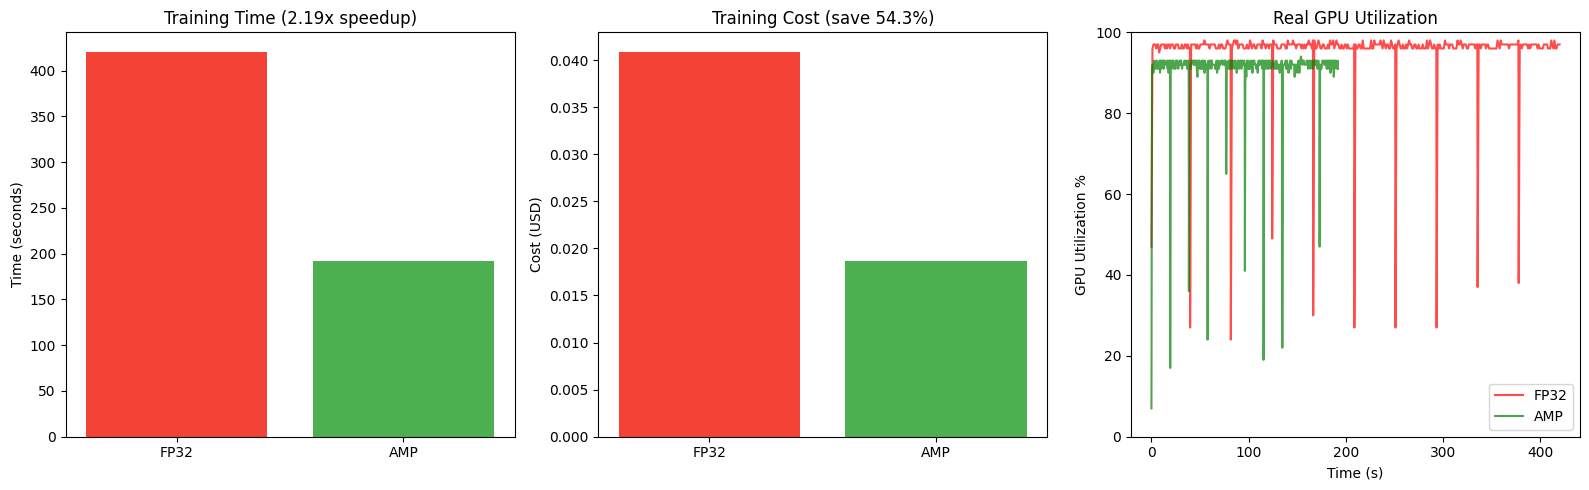

In [29]:
# Cell 24: Compare FP32 vs AMP - FinOps Analysis
if "display_student_header" in globals():
    display_student_header()

print("=" * 60)
print("FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)")
print("=" * 60)

speedup = fp32_total_time / amp_total_time
cost_saving = fp32_cost - amp_cost
cost_saving_pct = (cost_saving / fp32_cost) * 100 if fp32_cost > 0 else 0
mem_saving = fp32_peak_mem - amp_peak_mem

print(f"\n{'Metric':<25} {'FP32':<15} {'AMP':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Total Time':<25} {fp32_total_time:<15.1f} {amp_total_time:<15.1f} {speedup:.2f}x faster")
print(f"{'Peak Memory (GB)':<25} {fp32_peak_mem:<15.2f} {amp_peak_mem:<15.2f} {mem_saving:.2f} GB saved")
print(f"{'Cost (USD)':<25} ${fp32_cost:<14.6f} ${amp_cost:<14.6f} ${cost_saving:.6f} saved")
print(f"{'Cost Saving %':<25} {'---':<15} {'---':<15} {cost_saving_pct:.1f}%")

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    print(f"{'Avg GPU Util %':<25} {fp32_monitor_df['gpu_util_pct'].mean():<15.1f} {amp_monitor_df['gpu_util_pct'].mean():<15.1f}")
    print(f"{'Avg Power (W)':<25} {fp32_monitor_df['power_watts'].mean():<15.1f} {amp_monitor_df['power_watts'].mean():<15.1f}")

# Extrapolate to larger scale
print(f"\n--- Extrapolated Savings at Scale ---")
for scale_name, hours in [("1 day training", 24), ("1 week training", 168), ("1 month training", 720)]:
    fp32_scaled = hours * price_per_hour
    amp_scaled = (hours / speedup) * price_per_hour
    saved = fp32_scaled - amp_scaled
    print(f"   {scale_name}: FP32=${fp32_scaled:.2f} vs AMP=${amp_scaled:.2f} -> SAVE ${saved:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: Time comparison
axes[0].bar(['FP32', 'AMP'], [fp32_total_time, amp_total_time], color=['#F44336', '#4CAF50'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Training Time ({speedup:.2f}x speedup)')

# Bar: Cost comparison
axes[1].bar(['FP32', 'AMP'], [fp32_cost, amp_cost], color=['#F44336', '#4CAF50'])
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Training Cost (save {cost_saving_pct:.1f}%)')

# Line: GPU utilization over time (both experiments) or epoch time
if has_monitor_data:
    if not fp32_monitor_df.empty:
        axes[2].plot(fp32_monitor_df['elapsed'], fp32_monitor_df['gpu_util_pct'], 'r-', alpha=0.7, label='FP32')
    if not amp_monitor_df.empty:
        axes[2].plot(amp_monitor_df['elapsed'], amp_monitor_df['gpu_util_pct'], 'g-', alpha=0.7, label='AMP')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('GPU Utilization %')
    axes[2].set_title('Real GPU Utilization')
    axes[2].legend()
    axes[2].set_ylim(0, 100)
else:
    # Fallback: show epoch times
    epochs = list(range(1, NUM_EPOCHS + 1))
    axes[2].plot(epochs, [r['time_s'] for r in fp32_results], 'r-o', label='FP32')
    axes[2].plot(epochs, [r['time_s'] for r in amp_results], 'g-o', label='AMP')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Time (s)')
    axes[2].set_title('Time per Epoch')
    axes[2].legend()

plt.tight_layout()
plt.savefig('real_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Cell 25: Report real GPU costs back to the FinOps Gateway
if "display_student_header" in globals():
    display_student_header()

print("=" * 60)
print("REPORTING REAL GPU COSTS TO FINOPS GATEWAY")
print("=" * 60)

# Report FP32 workload
fp32_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-fp32",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": fp32_total_time,
    "is_spot": False,
    "project": "real-gpu-lab",
}).json()
print(f"\n   FP32 workload reported:")
print(f"   Cost: ${fp32_report['total_cost_usd']:.6f} | Rate: ${fp32_report['rate_per_hour']:.4f}/hr")

# Report AMP workload (as spot - demonstrating cost optimization)
amp_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-amp",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": amp_total_time,
    "is_spot": True,
    "project": "real-gpu-lab",
}).json()
print(f"\n   AMP workload reported (as spot):")
print(f"   Cost: ${amp_report['total_cost_usd']:.6f} | Saved: ${amp_report['savings_usd']:.6f}")

# Submit workload info to cluster tracker
for wl_name, wl_time in [("real-gpu-resnet18-fp32", fp32_total_time), ("real-gpu-resnet18-amp", amp_total_time)]:
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": wl_name,
        "gpu_type_preferred": detected_type,
        "gpu_count": 1,
        "duration_seconds": int(wl_time),
    })

# Get updated billing summary including real GPU data
print(f"\n--- Updated FinOps Billing (incl. real GPU) ---")
summary = requests.get(f"{GATEWAY_URL}/billing/summary", params={"project": "real-gpu-lab"}).json()
print(f"   Project:         real-gpu-lab")
print(f"   Total Cost:      ${summary['total_cost_usd']:.6f}")
print(f"   Total Savings:   ${summary['total_savings_usd']:.6f}")
print(f"   Workloads:       {summary['total_workloads']}")

# Push real GPU metrics as a cost snapshot
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"\n   Cost snapshot taken: waste={snap['waste_pct']:.1f}%")

# Get final dashboard with everything
print(f"\n--- FINAL DASHBOARD (Mock + Real GPU) ---")
dash = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()
bs = dash.get('billing_summary', {})
print(f"   Total Platform Cost:  ${bs.get('total_cost_usd', 0):.4f}")
print(f"   Total Savings:        ${bs.get('total_savings_usd', 0):.4f}")
print(f"   Budget Utilization:   {bs.get('budget_utilization_pct', 0):.1f}%")
print(f"   Alert:                {bs.get('alert', 'N/A')}")

REPORTING REAL GPU COSTS TO FINOPS GATEWAY

   FP32 workload reported:
   Cost: $0.040900 | Rate: $0.3500/hr

   AMP workload reported (as spot):
   Cost: $0.005600 | Saved: $0.013100

--- Updated FinOps Billing (incl. real GPU) ---
   Project:         real-gpu-lab
   Total Cost:      $0.097700
   Total Savings:   $0.027600
   Workloads:       6

   Cost snapshot taken: waste=18.5%

--- FINAL DASHBOARD (Mock + Real GPU) ---
   Total Platform Cost:  $4.0920
   Total Savings:        $4.2453
   Budget Utilization:   4.1%
   Alert:                OK


Real GPU Telemetry During Training


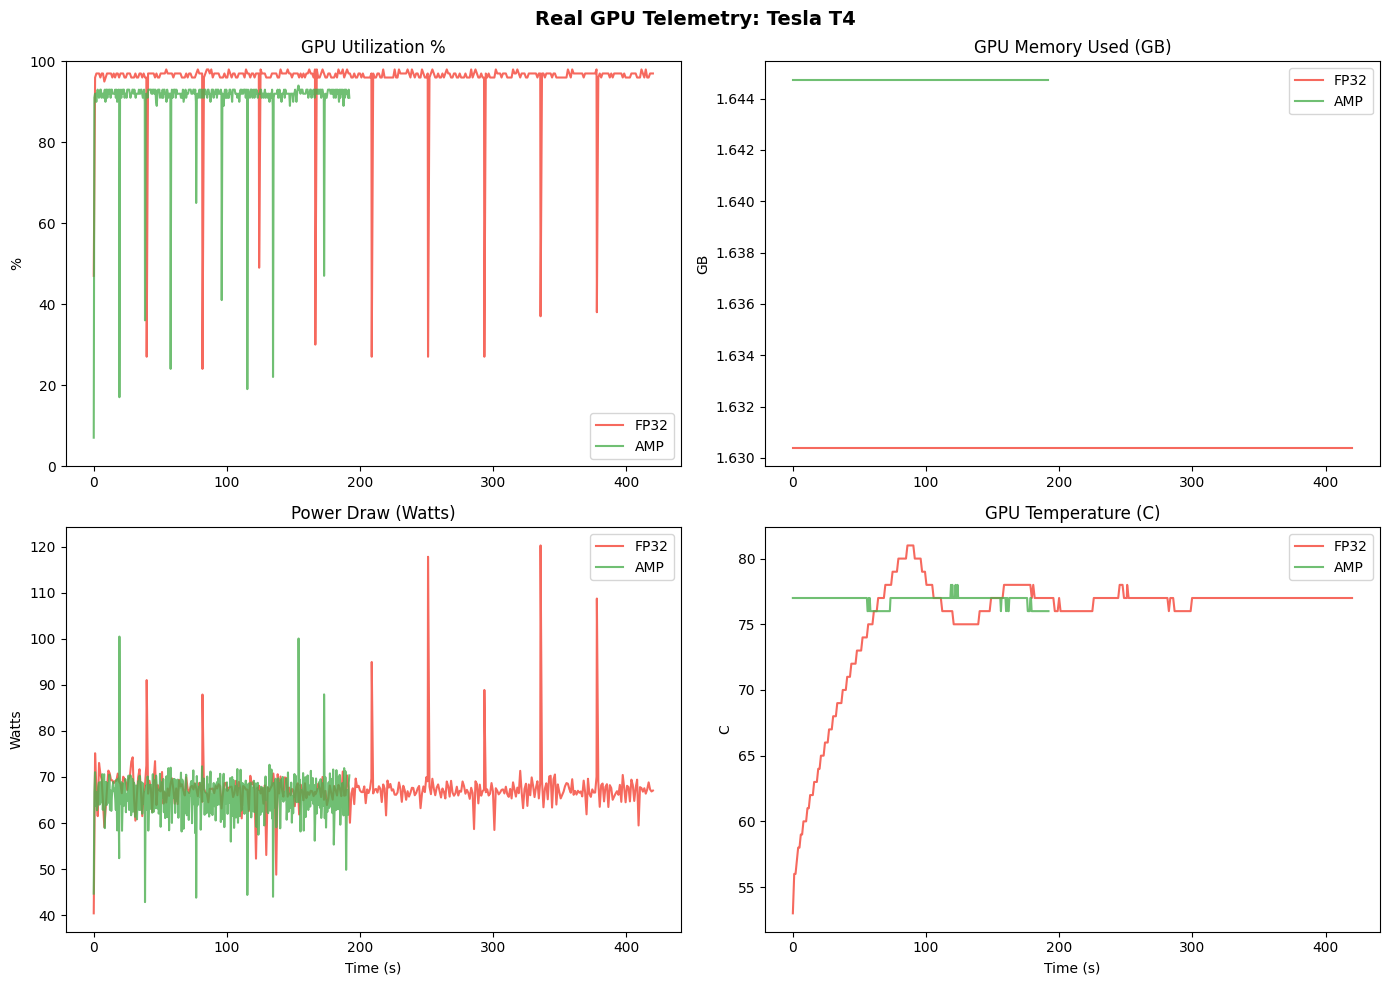

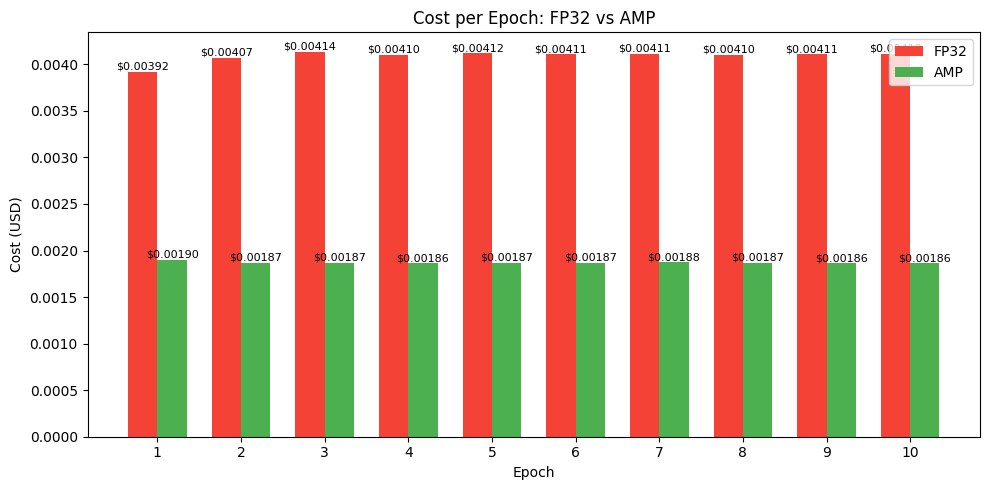


Charts saved: cost_per_epoch.png, real_gpu_telemetry.png


In [31]:
# Cell 26: Real GPU Monitoring Visualization
if "display_student_header" in globals():
    display_student_header()

print("Real GPU Telemetry During Training")
print("=" * 60)

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # GPU Utilization
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 0].plot(df['elapsed'], df['gpu_util_pct'], color=color, alpha=0.8, label=label)
    axes[0, 0].set_title('GPU Utilization %')
    axes[0, 0].set_ylabel('%')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 100)

    # Memory Usage
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 1].plot(df['elapsed'], df['mem_used_mb'] / 1024, color=color, alpha=0.8, label=label)
    axes[0, 1].set_title('GPU Memory Used (GB)')
    axes[0, 1].set_ylabel('GB')
    axes[0, 1].legend()

    # Power Draw
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 0].plot(df['elapsed'], df['power_watts'], color=color, alpha=0.8, label=label)
    axes[1, 0].set_title('Power Draw (Watts)')
    axes[1, 0].set_ylabel('Watts')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].legend()

    # Temperature
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 1].plot(df['elapsed'], df['temp_c'], color=color, alpha=0.8, label=label)
    axes[1, 1].set_title('GPU Temperature (C)')
    axes[1, 1].set_ylabel('C')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()

    plt.suptitle(f'Real GPU Telemetry: {gpu_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('real_gpu_telemetry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   GPU telemetry not available (monitor collected 0 samples).")
    print("   Showing epoch-level metrics instead.\n")

# Cost per epoch chart (always works)
fig, ax = plt.subplots(figsize=(10, 5))
fp32_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in fp32_results]
amp_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in amp_results]
epochs = list(range(1, NUM_EPOCHS + 1))

x = range(len(epochs))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], fp32_epoch_costs, width, label='FP32', color='#F44336')
bars2 = ax.bar([i + width/2 for i in x], amp_epoch_costs, width, label='AMP', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost per Epoch: FP32 vs AMP')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cost_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved: cost_per_epoch.png" + (", real_gpu_telemetry.png" if has_monitor_data else ""))

---
## Part 8.5: Advanced GPU Cost Optimization
Apply advanced FinOps techniques: multi-GPU cost analysis, project forecasting, and optimization strategy prioritization.

This section extends Part 8 with:
1. **Multi-GPU Cost Analysis** - Compare scaling efficiency and determine optimal GPU count
2. **Project Cost Forecasting** - Forecast multi-phase project costs with confidence intervals
3. **Optimization Opportunity Analysis** - Prioritize and combine optimization strategies

EXERCISE 8.5.1: Multi-GPU Cost Analysis

Multi-GPU cost comparison:


,GPUs,Speedup,Efficiency %,Time (h),Total Cost ($),Cost/Speedup
0,1,1.00x,100.0%,2.00,$7.34,$7.34
1,2,1.78x,89.0%,1.12,$8.25,$4.63
2,4,3.25x,81.2%,0.62,$9.03,$2.78
3,8,5.75x,71.9%,0.35,$10.21,$1.78



Lowest absolute cost: 1x A100 at $7.34
Balanced time/cost choice: 8x A100 (0.35h, $10.21)


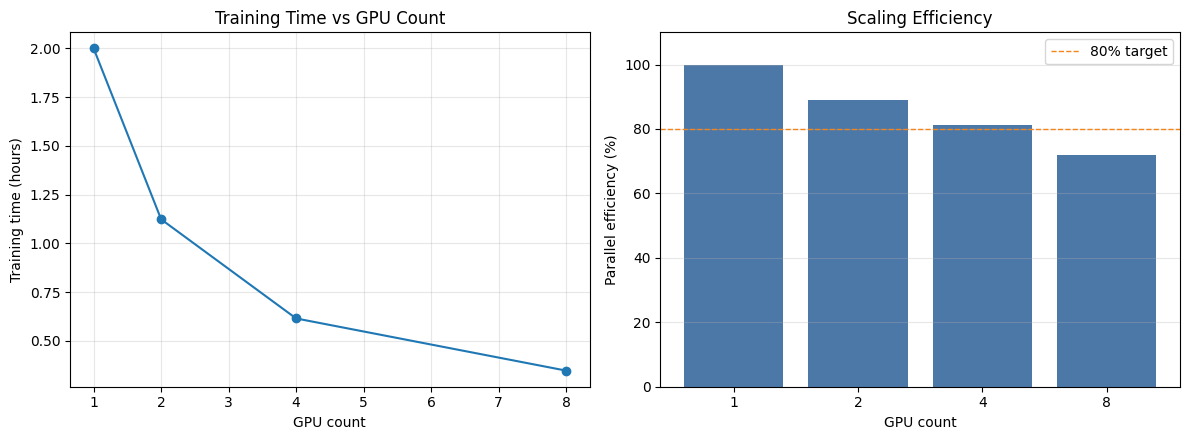


Chart saved as multi_gpu_scaling.png


In [32]:
# Cell 27: Multi-GPU Cost Analysis
if "display_student_header" in globals():
    display_student_header()

print("=" * 60)
print("EXERCISE 8.5.1: Multi-GPU Cost Analysis")
print("=" * 60)

if "GPU_PRICING" not in globals():
    GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}


def analyze_multi_gpu_cost(base_time_hours, gpu_type, gpu_counts, scaling_factors=None):
    """
    Compare training time, total cost, speedup, and efficiency for different GPU counts.

    scaling_factors stores effective speedup versus one GPU. For example, 2 GPUs at 1.75x
    means the workload is faster than one GPU but still has distributed training overhead.
    """
    if base_time_hours <= 0:
        raise ValueError("base_time_hours must be positive")
    if not gpu_counts:
        raise ValueError("gpu_counts must contain at least one option")

    price_per_hour = GPU_PRICING.get(gpu_type)
    if price_per_hour is None:
        raise ValueError(f"Unknown gpu_type={gpu_type}. Known types: {sorted(GPU_PRICING)}")

    default_scaling = {1: 1.0, 2: 1.78, 4: 3.25, 8: 5.75, 16: 9.50}
    scaling_factors = scaling_factors or {}

    rows = []
    for gpu_count in gpu_counts:
        if gpu_count <= 0:
            raise ValueError("gpu_counts must be positive")

        speedup = scaling_factors.get(gpu_count, default_scaling.get(gpu_count))
        if speedup is None:
            # Conservative fallback based on 78% parallel efficiency.
            speedup = 1 + (gpu_count - 1) * 0.78

        training_time_hours = base_time_hours / speedup
        total_cost = training_time_hours * gpu_count * price_per_hour
        parallel_efficiency = speedup / gpu_count
        cost_per_speedup = total_cost / speedup
        cost_delta_pct = ((total_cost / (base_time_hours * price_per_hour)) - 1) * 100

        rows.append({
            "gpu_count": gpu_count,
            "gpu_type": gpu_type,
            "speedup": speedup,
            "parallel_efficiency_pct": parallel_efficiency * 100,
            "training_time_hours": training_time_hours,
            "total_cost_usd": total_cost,
            "cost_per_speedup": cost_per_speedup,
            "cost_delta_vs_1gpu_pct": cost_delta_pct,
        })

    df = pd.DataFrame(rows)
    optimal_cost = df.loc[df["total_cost_usd"].idxmin()].to_dict()
    optimal_time_under_2x_cost = df[df["cost_delta_vs_1gpu_pct"] <= 100].sort_values("training_time_hours").head(1)
    balanced = optimal_time_under_2x_cost.iloc[0].to_dict() if not optimal_time_under_2x_cost.empty else optimal_cost

    return {
        "gpu_type": gpu_type,
        "price_per_hour": price_per_hour,
        "base_time_hours": base_time_hours,
        "rows": rows,
        "dataframe": df,
        "optimal_lowest_cost": optimal_cost,
        "balanced_choice": balanced,
    }


base_training_time = 2.0  # hours for single GPU
test_gpu_counts = [1, 2, 4, 8]

multi_gpu_analysis = analyze_multi_gpu_cost(base_training_time, "A100", test_gpu_counts)
multi_gpu_df = multi_gpu_analysis["dataframe"]

display_cols = [
    "gpu_count", "speedup", "parallel_efficiency_pct",
    "training_time_hours", "total_cost_usd", "cost_per_speedup",
]
display_df = multi_gpu_df[display_cols].copy()
display_df.columns = [
    "GPUs", "Speedup", "Efficiency %", "Time (h)", "Total Cost ($)", "Cost/Speedup",
]

print("\nMulti-GPU cost comparison:")
display(display_df.style.format({
    "Speedup": "{:.2f}x",
    "Efficiency %": "{:.1f}%",
    "Time (h)": "{:.2f}",
    "Total Cost ($)": "${:.2f}",
    "Cost/Speedup": "${:.2f}",
}))

best = multi_gpu_analysis["optimal_lowest_cost"]
balanced = multi_gpu_analysis["balanced_choice"]
print(f"\nLowest absolute cost: {int(best['gpu_count'])}x {best['gpu_type']} at ${best['total_cost_usd']:.2f}")
print(f"Balanced time/cost choice: {int(balanced['gpu_count'])}x {balanced['gpu_type']} "
      f"({balanced['training_time_hours']:.2f}h, ${balanced['total_cost_usd']:.2f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(multi_gpu_df["gpu_count"], multi_gpu_df["training_time_hours"], marker="o", label="Training time")
axes[0].set_xlabel("GPU count")
axes[0].set_ylabel("Training time (hours)")
axes[0].set_title("Training Time vs GPU Count")
axes[0].grid(True, alpha=0.3)

axes[1].bar(multi_gpu_df["gpu_count"].astype(str), multi_gpu_df["parallel_efficiency_pct"], color="#4C78A8")
axes[1].axhline(80, color="#F58518", linestyle="--", linewidth=1, label="80% target")
axes[1].set_xlabel("GPU count")
axes[1].set_ylabel("Parallel efficiency (%)")
axes[1].set_title("Scaling Efficiency")
axes[1].set_ylim(0, 110)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("multi_gpu_scaling.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved as multi_gpu_scaling.png")


EXERCISE 8.5.2: Project Cost Forecasting

Project forecast by phase:


,Phase,GPU,GPU Count,Hours,Expected ($),Best Case ($),Worst Case ($)
0,Data Preparation,T4,1,40.0,$14.00,$11.90,$16.10
1,Model Training,A100,4,120.0,$1761.60,$1321.20,$2202.00
2,Hyperparameter Tuning,A100,8,60.0,$1761.60,$1233.12,$2290.08
3,Model Evaluation,T4,2,20.0,$14.00,$12.60,$15.40



Base total:        $3551.20
Contingency:       $710.24
Expected total:    $4261.44
95% planning band: $2913.09 - $5609.79
Best/Worst case:   $2578.82 - $5233.82


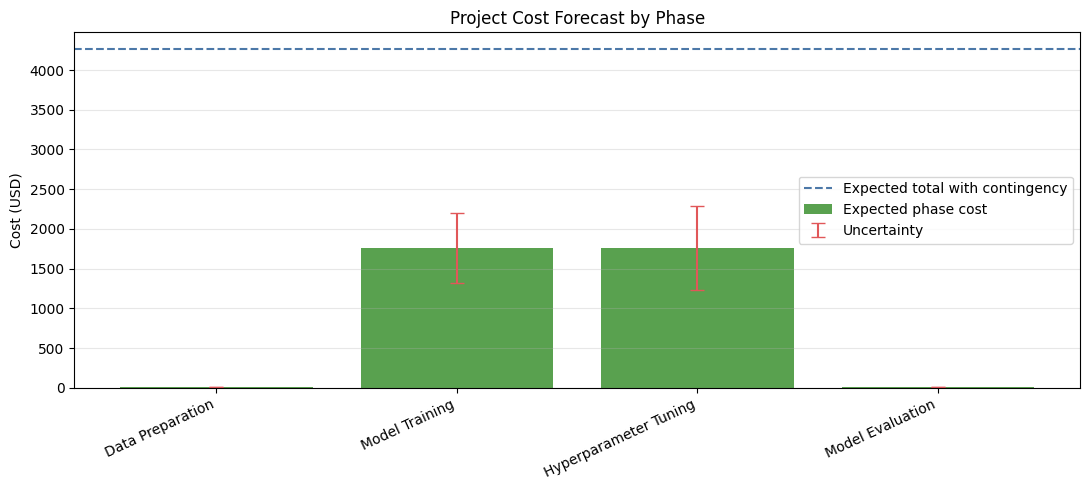


Chart saved as project_forecast.png


In [33]:
# Cell 28: Project Cost Forecasting
if "display_student_header" in globals():
    display_student_header()

print("=" * 60)
print("EXERCISE 8.5.2: Project Cost Forecasting")
print("=" * 60)

if "GPU_PRICING" not in globals():
    GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}


def forecast_project_cost(phases, contingency_pct=20, confidence_level=0.95):
    """
    Forecast a multi-phase GPU project with per-phase uncertainty and contingency.

    Uncertainty is modeled as a practical best/worst range around each phase cost.
    The confidence interval is a normal approximation using phase uncertainty as
    one standard deviation-like planning input.
    """
    if not phases:
        raise ValueError("phases must contain at least one phase")

    z_scores = {0.80: 1.28, 0.90: 1.64, 0.95: 1.96, 0.99: 2.58}
    z = z_scores.get(round(confidence_level, 2), 1.96)

    breakdown = []
    variance = 0.0
    for phase in phases:
        price = GPU_PRICING.get(phase["gpu_type"])
        if price is None:
            raise ValueError(f"Unknown gpu_type={phase['gpu_type']}")

        base_cost = price * phase["gpu_count"] * phase["duration_hours"]
        uncertainty_pct = phase.get("uncertainty_pct", 0.20)
        low_cost = base_cost * (1 - uncertainty_pct)
        high_cost = base_cost * (1 + uncertainty_pct)
        variance += (base_cost * uncertainty_pct) ** 2

        breakdown.append({
            **phase,
            "price_per_hour": price,
            "base_cost_usd": base_cost,
            "low_cost_usd": low_cost,
            "high_cost_usd": high_cost,
        })

    base_total = sum(p["base_cost_usd"] for p in breakdown)
    contingency = base_total * (contingency_pct / 100)
    expected_total = base_total + contingency
    std_dev = variance ** 0.5
    ci_low = max(0, expected_total - z * std_dev)
    ci_high = expected_total + z * std_dev

    return {
        "breakdown": breakdown,
        "dataframe": pd.DataFrame(breakdown),
        "base_total_usd": base_total,
        "contingency_usd": contingency,
        "expected_total_usd": expected_total,
        "confidence_level": confidence_level,
        "confidence_interval_usd": (ci_low, ci_high),
        "best_case_usd": sum(p["low_cost_usd"] for p in breakdown),
        "worst_case_usd": sum(p["high_cost_usd"] for p in breakdown) + contingency,
    }


example_project = [
    {"name": "Data Preparation", "gpu_type": "T4", "gpu_count": 1, "duration_hours": 40, "uncertainty_pct": 0.15},
    {"name": "Model Training", "gpu_type": "A100", "gpu_count": 4, "duration_hours": 120, "uncertainty_pct": 0.25},
    {"name": "Hyperparameter Tuning", "gpu_type": "A100", "gpu_count": 8, "duration_hours": 60, "uncertainty_pct": 0.30},
    {"name": "Model Evaluation", "gpu_type": "T4", "gpu_count": 2, "duration_hours": 20, "uncertainty_pct": 0.10},
]

project_forecast = forecast_project_cost(example_project, contingency_pct=20, confidence_level=0.95)
forecast_df = project_forecast["dataframe"]

print("\nProject forecast by phase:")
phase_display = forecast_df[[
    "name", "gpu_type", "gpu_count", "duration_hours",
    "base_cost_usd", "low_cost_usd", "high_cost_usd",
]].copy()
phase_display.columns = ["Phase", "GPU", "GPU Count", "Hours", "Expected ($)", "Best Case ($)", "Worst Case ($)"]
display(phase_display.style.format({
    "Hours": "{:.1f}",
    "Expected ($)": "${:.2f}",
    "Best Case ($)": "${:.2f}",
    "Worst Case ($)": "${:.2f}",
}))

ci_low, ci_high = project_forecast["confidence_interval_usd"]
print(f"\nBase total:        ${project_forecast['base_total_usd']:.2f}")
print(f"Contingency:       ${project_forecast['contingency_usd']:.2f}")
print(f"Expected total:    ${project_forecast['expected_total_usd']:.2f}")
print(f"95% planning band: ${ci_low:.2f} - ${ci_high:.2f}")
print(f"Best/Worst case:   ${project_forecast['best_case_usd']:.2f} - ${project_forecast['worst_case_usd']:.2f}")

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(forecast_df))
base = forecast_df["base_cost_usd"]
lower_err = base - forecast_df["low_cost_usd"]
upper_err = forecast_df["high_cost_usd"] - base
ax.bar(x, base, color="#59A14F", label="Expected phase cost")
ax.errorbar(x, base, yerr=[lower_err, upper_err], fmt="none", ecolor="#E15759", capsize=5, label="Uncertainty")
ax.axhline(project_forecast["expected_total_usd"], color="#4C78A8", linestyle="--", label="Expected total with contingency")
ax.set_xticks(x)
ax.set_xticklabels(forecast_df["name"], rotation=25, ha="right")
ax.set_ylabel("Cost (USD)")
ax.set_title("Project Cost Forecast by Phase")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("project_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved as project_forecast.png")


EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis

Baseline cost: $1468.00

Prioritized optimization roadmap:


,Order,Strategy,Savings %,Effort,Risk,Priority,Incremental Save ($),Cumulative Save %,Remaining Cost ($)
0,1,Switch to Mixed Precision (AMP),25%,LOW,LOW,25.00,$367.00,25.0%,$1101.00
1,2,Optimize Batch Size,15%,LOW,LOW,15.00,$165.15,36.2%,$935.85
2,3,Use Spot Instances,60%,MEDIUM,HIGH,10.00,$561.51,74.5%,$374.34
3,4,Implement Early Stopping,20%,MEDIUM,LOW,10.00,$74.87,79.6%,$299.47
4,5,Switch to More Efficient GPU Type,40%,HIGH,MEDIUM,6.67,$119.79,87.8%,$179.68



Final projected cost after roadmap: $179.68
Total compounded savings: $1288.32 (87.8%)


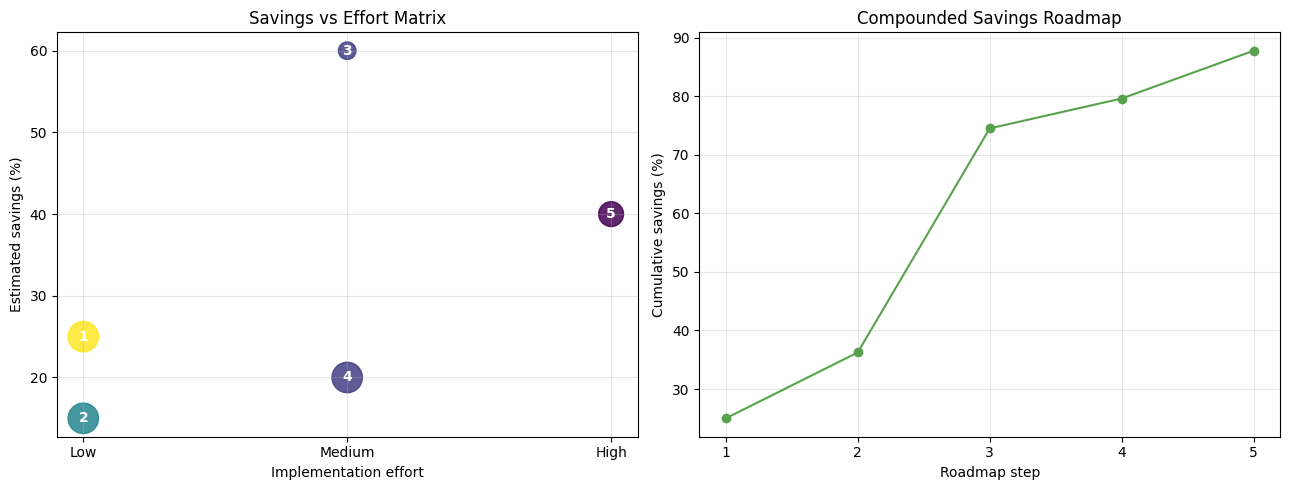


Chart saved as optimization_roadmap.png


In [34]:
# Cell 29: Optimization Opportunity Analysis
if "display_student_header" in globals():
    display_student_header()

print("=" * 60)
print("EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis")
print("=" * 60)

if "GPU_PRICING" not in globals():
    GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}


def analyze_optimization_opportunities(current_config, optimization_strategies):
    """
    Rank optimization strategies by savings, effort, risk, and dependency readiness.
    Cumulative savings are compounded because each optimization reduces the remaining spend.
    """
    effort_score = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
    risk_score = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}

    base_hourly = GPU_PRICING[current_config["gpu_type"]] * current_config["gpu_count"]
    baseline_cost = base_hourly * current_config["duration_hours"]

    analyzed = []
    strategy_names = {s["name"] for s in optimization_strategies}
    for strategy in optimization_strategies:
        effort = effort_score.get(strategy["implementation_effort"], 2)
        risk = risk_score.get(strategy["risk_level"], 2)
        dependencies = strategy.get("dependencies", [])
        missing_dependencies = [dep for dep in dependencies if dep not in strategy_names]
        dependency_penalty = 1 + (0.25 * len(missing_dependencies))

        potential_savings = baseline_cost * strategy["savings_pct"]
        priority_score = (strategy["savings_pct"] * 100) / (effort * risk * dependency_penalty)

        analyzed.append({
            **strategy,
            "baseline_cost_usd": baseline_cost,
            "potential_savings_usd": potential_savings,
            "effort_score": effort,
            "risk_score": risk,
            "missing_dependencies": missing_dependencies,
            "priority_score": priority_score,
        })

    prioritized = sorted(analyzed, key=lambda item: item["priority_score"], reverse=True)

    remaining_cost = baseline_cost
    roadmap = []
    for order, strategy in enumerate(prioritized, 1):
        incremental_savings = remaining_cost * strategy["savings_pct"]
        remaining_cost -= incremental_savings
        roadmap.append({
            **strategy,
            "order": order,
            "incremental_savings_usd": incremental_savings,
            "remaining_cost_usd": remaining_cost,
            "cumulative_savings_usd": baseline_cost - remaining_cost,
            "cumulative_savings_pct": (1 - remaining_cost / baseline_cost) * 100,
        })

    return {
        "baseline_cost_usd": baseline_cost,
        "prioritized": prioritized,
        "roadmap": roadmap,
        "dataframe": pd.DataFrame(roadmap),
        "final_cost_usd": remaining_cost,
        "total_savings_usd": baseline_cost - remaining_cost,
        "total_savings_pct": (1 - remaining_cost / baseline_cost) * 100,
    }


example_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Spot Instances", "savings_pct": 0.60, "implementation_effort": "MEDIUM", "risk_level": "HIGH", "dependencies": []},
    {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Implement Early Stopping", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
    {"name": "Switch to More Efficient GPU Type", "savings_pct": 0.40, "implementation_effort": "HIGH", "risk_level": "MEDIUM", "dependencies": []},
]

current_training_config = {
    "gpu_type": "A100",
    "gpu_count": 4,
    "duration_hours": 100,
    "precision": "FP32",
    "instance_type": "on-demand",
}

optimization_recommendations = analyze_optimization_opportunities(current_training_config, example_strategies)
optimization_df = optimization_recommendations["dataframe"]

print(f"\nBaseline cost: ${optimization_recommendations['baseline_cost_usd']:.2f}")
print("\nPrioritized optimization roadmap:")
roadmap_display = optimization_df[[
    "order", "name", "savings_pct", "implementation_effort", "risk_level",
    "priority_score", "incremental_savings_usd", "cumulative_savings_pct", "remaining_cost_usd",
]].copy()
roadmap_display.columns = [
    "Order", "Strategy", "Savings %", "Effort", "Risk",
    "Priority", "Incremental Save ($)", "Cumulative Save %", "Remaining Cost ($)",
]
display(roadmap_display.style.format({
    "Savings %": "{:.0%}",
    "Priority": "{:.2f}",
    "Incremental Save ($)": "${:.2f}",
    "Cumulative Save %": "{:.1f}%",
    "Remaining Cost ($)": "${:.2f}",
}))

print(f"\nFinal projected cost after roadmap: ${optimization_recommendations['final_cost_usd']:.2f}")
print(f"Total compounded savings: ${optimization_recommendations['total_savings_usd']:.2f} "
      f"({optimization_recommendations['total_savings_pct']:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(
    optimization_df["effort_score"],
    optimization_df["savings_pct"] * 100,
    s=(4 - optimization_df["risk_score"]) * 160,
    c=optimization_df["priority_score"],
    cmap="viridis",
    alpha=0.85,
)
for _, row in optimization_df.iterrows():
    axes[0].annotate(str(int(row["order"])), (row["effort_score"], row["savings_pct"] * 100),
                     ha="center", va="center", color="white", weight="bold")
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(["Low", "Medium", "High"])
axes[0].set_xlabel("Implementation effort")
axes[0].set_ylabel("Estimated savings (%)")
axes[0].set_title("Savings vs Effort Matrix")
axes[0].grid(True, alpha=0.3)

axes[1].plot(optimization_df["order"], optimization_df["cumulative_savings_pct"], marker="o", color="#59A14F")
axes[1].set_xticks(optimization_df["order"])
axes[1].set_xlabel("Roadmap step")
axes[1].set_ylabel("Cumulative savings (%)")
axes[1].set_title("Compounded Savings Roadmap")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("optimization_roadmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved as optimization_roadmap.png")


EXERCISE 8.5.4: Integrated Cost Dashboard


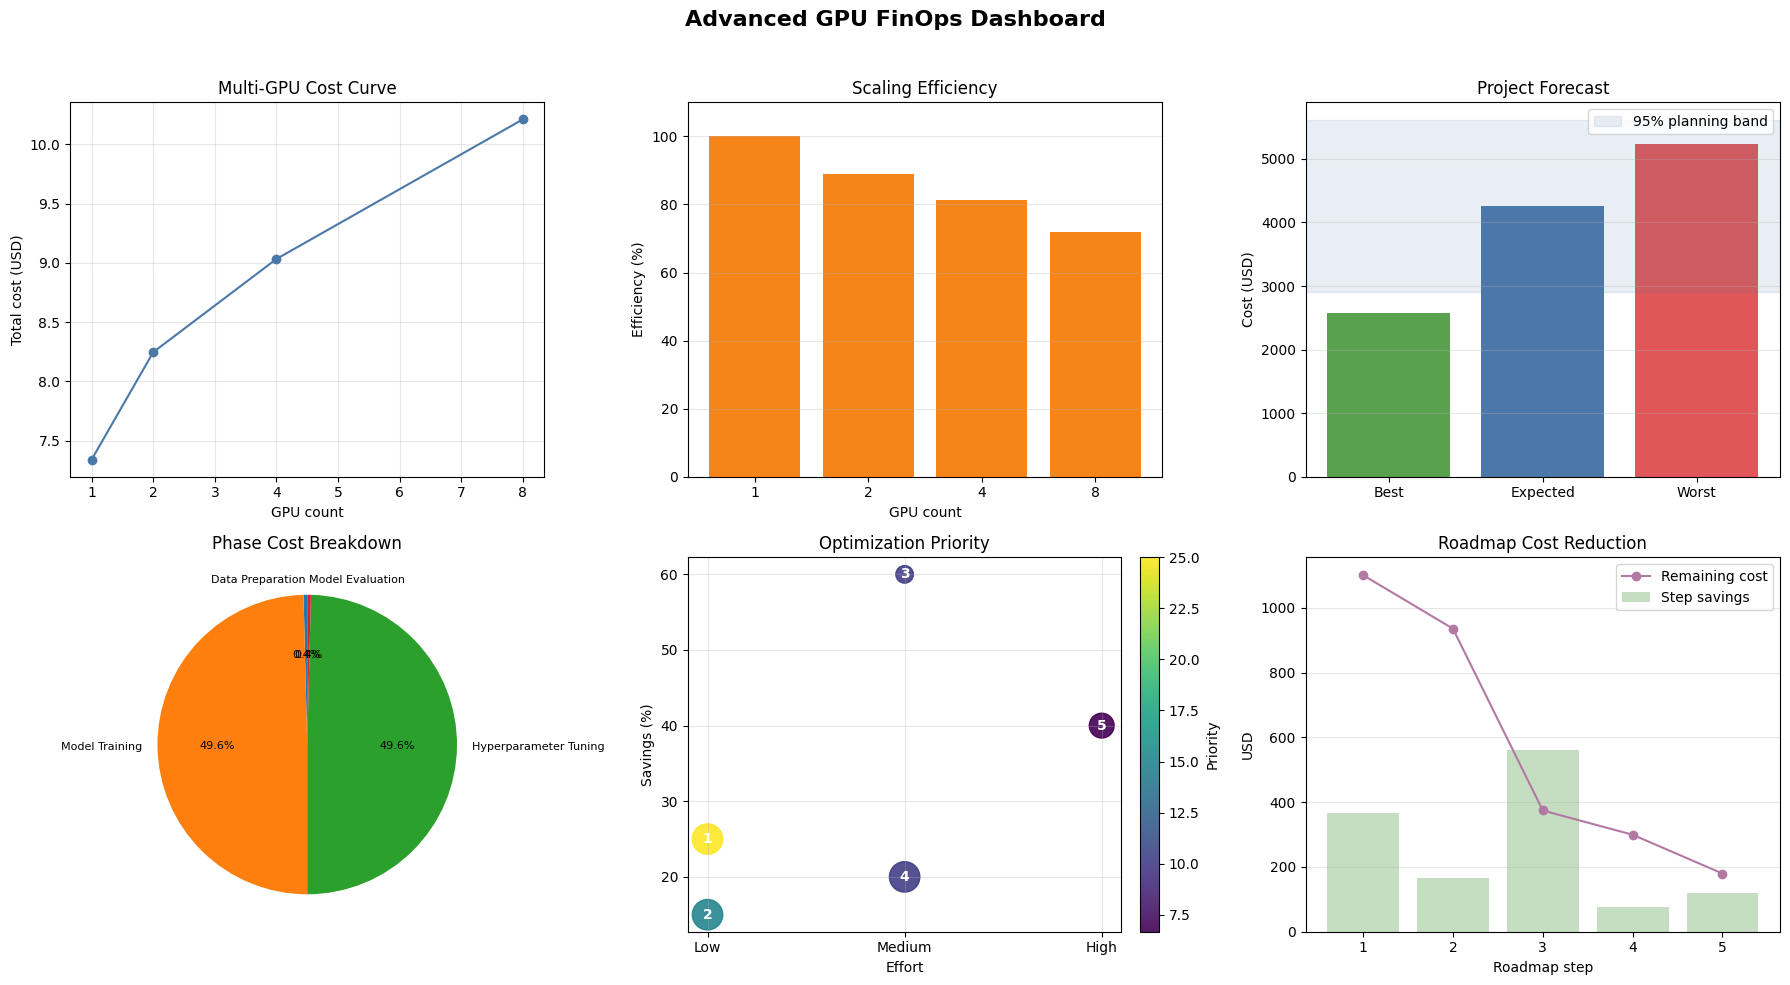


Dashboard saved as advanced_finops_dashboard.png


In [35]:
# Cell 30: Integrated Cost Dashboard
if "display_student_header" in globals():
    display_student_header()

print("=" * 60)
print("EXERCISE 8.5.4: Integrated Cost Dashboard")
print("=" * 60)


def create_advanced_finops_dashboard(multi_gpu_analysis, project_forecast, optimization_recommendations):
    """Create a six-panel dashboard for the advanced FinOps analysis."""
    multi_df = multi_gpu_analysis["dataframe"]
    forecast_df = project_forecast["dataframe"]
    opt_df = optimization_recommendations["dataframe"]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    axes[0].plot(multi_df["gpu_count"], multi_df["total_cost_usd"], marker="o", color="#4C78A8")
    axes[0].set_title("Multi-GPU Cost Curve")
    axes[0].set_xlabel("GPU count")
    axes[0].set_ylabel("Total cost (USD)")
    axes[0].grid(True, alpha=0.3)

    axes[1].bar(multi_df["gpu_count"].astype(str), multi_df["parallel_efficiency_pct"], color="#F58518")
    axes[1].set_title("Scaling Efficiency")
    axes[1].set_xlabel("GPU count")
    axes[1].set_ylabel("Efficiency (%)")
    axes[1].set_ylim(0, 110)
    axes[1].grid(axis="y", alpha=0.3)

    scenarios = ["Best", "Expected", "Worst"]
    scenario_values = [
        project_forecast["best_case_usd"],
        project_forecast["expected_total_usd"],
        project_forecast["worst_case_usd"],
    ]
    axes[2].bar(scenarios, scenario_values, color=["#59A14F", "#4C78A8", "#E15759"])
    ci_low, ci_high = project_forecast["confidence_interval_usd"]
    axes[2].axhspan(ci_low, ci_high, color="#4C78A8", alpha=0.12, label="95% planning band")
    axes[2].set_title("Project Forecast")
    axes[2].set_ylabel("Cost (USD)")
    axes[2].legend()
    axes[2].grid(axis="y", alpha=0.3)

    axes[3].pie(
        forecast_df["base_cost_usd"],
        labels=forecast_df["name"],
        autopct="%1.1f%%",
        startangle=90,
        textprops={"fontsize": 8},
    )
    axes[3].set_title("Phase Cost Breakdown")

    scatter = axes[4].scatter(
        opt_df["effort_score"],
        opt_df["savings_pct"] * 100,
        s=(4 - opt_df["risk_score"]) * 160,
        c=opt_df["priority_score"],
        cmap="viridis",
        alpha=0.9,
    )
    for _, row in opt_df.iterrows():
        axes[4].annotate(str(int(row["order"])), (row["effort_score"], row["savings_pct"] * 100),
                         ha="center", va="center", color="white", weight="bold")
    axes[4].set_xticks([1, 2, 3])
    axes[4].set_xticklabels(["Low", "Medium", "High"])
    axes[4].set_xlabel("Effort")
    axes[4].set_ylabel("Savings (%)")
    axes[4].set_title("Optimization Priority")
    axes[4].grid(True, alpha=0.3)
    fig.colorbar(scatter, ax=axes[4], fraction=0.046, pad=0.04, label="Priority")

    axes[5].plot(opt_df["order"], opt_df["remaining_cost_usd"], marker="o", color="#B279A2", label="Remaining cost")
    axes[5].bar(opt_df["order"], opt_df["incremental_savings_usd"], alpha=0.35, color="#59A14F", label="Step savings")
    axes[5].set_title("Roadmap Cost Reduction")
    axes[5].set_xlabel("Roadmap step")
    axes[5].set_ylabel("USD")
    axes[5].set_xticks(opt_df["order"])
    axes[5].legend()
    axes[5].grid(axis="y", alpha=0.3)

    plt.suptitle("Advanced GPU FinOps Dashboard", fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig


advanced_dashboard_fig = create_advanced_finops_dashboard(
    multi_gpu_analysis,
    project_forecast,
    optimization_recommendations,
)
advanced_dashboard_fig.savefig("advanced_finops_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nDashboard saved as advanced_finops_dashboard.png")


In [36]:
# Cell 31: Challenge Exercise - Cost Optimization Strategy Design
if "display_student_header" in globals():
    display_student_header()

print("=" * 60)
print("CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy")
print("=" * 60)

challenge_scenario = {
    "project": "Large Language Model Fine-tuning",
    "requirements": {
        "training_duration": 200,  # hours baseline
        "gpu_type": "A100",
        "gpu_count": 8,
        "precision": "FP32",
        "instance_type": "on-demand",
        "budget": 5000,  # USD
    },
    "constraints": {
        "max_preemption_risk": "MEDIUM",
        "min_accuracy": 0.95,
        "deadline": "2 weeks",
    }
}

req = challenge_scenario["requirements"]
constraints = challenge_scenario["constraints"]
baseline_cost = GPU_PRICING[req["gpu_type"]] * req["gpu_count"] * req["training_duration"]

print("CHALLENGE SCENARIO:")
print(f"   Project: {challenge_scenario['project']}")
print(f"   Baseline: {req['gpu_count']}x {req['gpu_type']} for {req['training_duration']}h")
print(f"   Budget: ${req['budget']}")
print(f"   Deadline: {constraints['deadline']}")
print(f"   Baseline cost: ${baseline_cost:.2f}")

# Use multi-GPU analysis to compare alternatives for the 200h baseline.
challenge_gpu_analysis = analyze_multi_gpu_cost(
    base_time_hours=req["training_duration"],
    gpu_type=req["gpu_type"],
    gpu_counts=[1, 2, 4, 8],
)
challenge_df = challenge_gpu_analysis["dataframe"]

# Choose a practical plan: reduce to 4 GPUs for better cost efficiency, then apply
# low/medium risk optimizations that do not violate the MEDIUM preemption-risk constraint.
selected_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Implement Early Stopping", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Managed Spot for Checkpointed Jobs", "savings_pct": 0.35, "implementation_effort": "MEDIUM", "risk_level": "MEDIUM", "dependencies": ["Implement Early Stopping"]},
]

optimized_config = {
    "gpu_type": "A100",
    "gpu_count": 4,
    "duration_hours": float(challenge_df.loc[challenge_df["gpu_count"] == 4, "training_time_hours"].iloc[0]),
    "precision": "AMP",
    "instance_type": "mixed on-demand/spot",
}
challenge_optimization = analyze_optimization_opportunities(optimized_config, selected_strategies)

optimized_compute_cost = challenge_optimization["final_cost_usd"]
challenge_phases = [
    {"name": "Data validation", "gpu_type": "T4", "gpu_count": 1, "duration_hours": 20, "uncertainty_pct": 0.10},
    {"name": "Fine-tuning optimized", "gpu_type": "A100", "gpu_count": 4, "duration_hours": optimized_config["duration_hours"], "uncertainty_pct": 0.20},
    {"name": "Evaluation and rollback tests", "gpu_type": "T4", "gpu_count": 2, "duration_hours": 16, "uncertainty_pct": 0.10},
]
challenge_forecast = forecast_project_cost(challenge_phases, contingency_pct=15, confidence_level=0.95)

# Replace the raw fine-tuning phase estimate with the compounded optimized compute cost.
non_training_cost = (
    GPU_PRICING["T4"] * 1 * 20
    + GPU_PRICING["T4"] * 2 * 16
)
final_expected_cost = non_training_cost + optimized_compute_cost
final_with_contingency = final_expected_cost * 1.15
budget_margin = req["budget"] - final_with_contingency

print("\nMulti-GPU options for baseline workload:")
challenge_display = challenge_df[["gpu_count", "speedup", "training_time_hours", "total_cost_usd", "parallel_efficiency_pct"]].copy()
challenge_display.columns = ["GPUs", "Speedup", "Time (h)", "Raw Cost ($)", "Efficiency %"]
display(challenge_display.style.format({
    "Speedup": "{:.2f}x",
    "Time (h)": "{:.1f}",
    "Raw Cost ($)": "${:.2f}",
    "Efficiency %": "{:.1f}%",
}))

print("\nSelected strategy:")
print("   1. Use 4x A100 instead of 8x A100 because it keeps good speedup with much better efficiency.")
print("   2. Enable AMP, tune batch size, and add early stopping as low-risk savings.")
print("   3. Use managed spot only for checkpointed/retry-safe jobs to stay within MEDIUM preemption risk.")
print("   4. Keep evaluation on T4 because it is cheaper and does not need A100 throughput.")

print("\nOptimization roadmap:")
roadmap_cols = ["order", "name", "savings_pct", "risk_level", "remaining_cost_usd", "cumulative_savings_pct"]
display(challenge_optimization["dataframe"][roadmap_cols].style.format({
    "savings_pct": "{:.0%}",
    "remaining_cost_usd": "${:.2f}",
    "cumulative_savings_pct": "{:.1f}%",
}))

print("\nFinal cost check:")
print(f"   Optimized training cost: ${optimized_compute_cost:.2f}")
print(f"   Non-training GPU cost:   ${non_training_cost:.2f}")
print(f"   Expected total:          ${final_expected_cost:.2f}")
print(f"   With 15% contingency:    ${final_with_contingency:.2f}")
print(f"   Budget margin:           ${budget_margin:.2f}")
print(f"   Under budget:            {'YES' if budget_margin >= 0 else 'NO'}")
print(f"   Meets risk constraint:   YES (spot limited to checkpointed work)")
print(f"   Accuracy constraint:     Preserve >= {constraints['min_accuracy']:.0%} with validation gate before rollout")

print("\nConclusion:")
print("   Recommended plan is feasible under the $5,000 budget and preserves schedule flexibility.")
print("   The largest savings come from right-sizing GPU count, AMP, and controlled spot usage.")


CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy
CHALLENGE SCENARIO:
   Project: Large Language Model Fine-tuning
   Baseline: 8x A100 for 200h
   Budget: $5000
   Deadline: 2 weeks
   Baseline cost: $5872.00

Multi-GPU options for baseline workload:


,GPUs,Speedup,Time (h),Raw Cost ($),Efficiency %
0,1,1.00x,200.0,$734.00,100.0%
1,2,1.78x,112.4,$824.72,89.0%
2,4,3.25x,61.5,$903.38,81.2%
3,8,5.75x,34.8,$1021.22,71.9%



Selected strategy:
   1. Use 4x A100 instead of 8x A100 because it keeps good speedup with much better efficiency.
   2. Enable AMP, tune batch size, and add early stopping as low-risk savings.
   3. Use managed spot only for checkpointed/retry-safe jobs to stay within MEDIUM preemption risk.
   4. Keep evaluation on T4 because it is cheaper and does not need A100 throughput.

Optimization roadmap:


,order,name,savings_pct,risk_level,remaining_cost_usd,cumulative_savings_pct
0,1,Switch to Mixed Precision (AMP),25%,LOW,$677.54,25.0%
1,2,Optimize Batch Size,15%,LOW,$575.91,36.3%
2,3,Implement Early Stopping,20%,LOW,$460.73,49.0%
3,4,Use Managed Spot for Checkpointed Jobs,35%,MEDIUM,$299.47,66.9%



Final cost check:
   Optimized training cost: $299.47
   Non-training GPU cost:   $18.20
   Expected total:          $317.67
   With 15% contingency:    $365.32
   Budget margin:           $4634.68
   Under budget:            YES
   Meets risk constraint:   YES (spot limited to checkpointed work)
   Accuracy constraint:     Preserve >= 95% with validation gate before rollout

Conclusion:
   Recommended plan is feasible under the $5,000 budget and preserves schedule flexibility.
   The largest savings come from right-sizing GPU count, AMP, and controlled spot usage.


---
## Summary

| Part | What | Where |
|------|------|-------|
| 1-5 | Mock cluster monitoring, billing, spot, autoscaling, cost tracking | Docker Compose (local) via tunnel |
| 6 | Visualization of mock FinOps data | Kaggle/Colab |
| 7 | End-to-end FinOps workflow | Both |
| **8** | **Real GPU training (ResNet-18), FP32 vs AMP, live monitoring, cost reporting** | **Kaggle/Colab GPU → Gateway** |

### Key FinOps Takeaways
- **Mixed Precision (AMP)** reduces training time and cost with minimal accuracy loss
- **Spot instances** save 60-70% but risk preemption
- **Autoscaling** prevents over-provisioning idle GPUs
- **Cost tracking** exposes waste from idle resources
- **Budget alerts** prevent unexpected overspend

---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** — measures time & cost savings
4. Reports all costs back to the FinOps gateway